# Lab 7: Great British Bake Off (A/B Test)

**Attention:**

1. **Using the Notebook**
    - Use Jupyter Notebook as instructed. We do **not** have the resources to support Anaconda or VS Code. 
    - Provide your answers in the designated spaces.
    - Do not reassign variables! For example, if you use `max_temperature` for one question, do not reassign it later on (e.g., as an intermediate variable). Doing so may cauae you to fail tests you passed previously!
2. **Grading**:
    - Points may be scaled in Canvas.
    - Most tests check the format and data types of your answers, not their correctness. Passing the tests does not guarantee the grade will be 100%.
3. Academic honor:
    - **DO NOT CHEAT!** Academic honor matters.  
    - <font color='darkred'>**Use AI to LEARN, not to cheat**. **DO NOT copy-and-paste**</font>. Your advantage comes from your knowledge and skills on the subject. Do not rely on AI. 
    - Collaboration and using resources are encouraged, but **DO NOT directly share answers**. Always answer the questions and solve the problems by yourself. 
4. Getting help:
    - Attend the TA's help sessions and the instructor's office hours.
5. <font color="darkred">**Time management**</font>: Start early in the assignment cycle and allocate enough time to complete the assignment properly.

**Reference Materials**:
- [Python Reference sp25](https://www.data8.org/sp24/reference/) or [Python Reference sp24](https://www.data8.org/sp24/reference/).
- The [Data8 datascience Reference](https://www.data8.org/datascience).
  
**Recommended Readings:**
* [CH11.4. Error Probabilities](https://introdsm.org/chapters/11/4/Error_Probabilities.html)
* [CH12.1. A/B Testing](https://introdsm.org/chapters/12/1/AB_Testing.html)

In [24]:
# Initialize Otter
import otter
grader = otter.Notebook("lab07.ipynb")

In [25]:
# Run this cell to set up the notebook, but please don't change it.

# These lines import the Numpy and Datascience modules.
import numpy as np
import pandas as pd
from datascience import *

# These lines do some fancy plotting magic.
import matplotlib.pyplot as plots
%matplotlib inline
plots.style.use('fivethirtyeight')

import warnings
# warnings.simplefilter('ignore', (FutureWarning, np.VisibleDeprecationWarning))
warnings.simplefilter('ignore', (FutureWarning, np.exceptions.VisibleDeprecationWarning))

## 1. A/B Testing

A/B testing is a form of hypothesis testing that allows you to make comparisons between two distributions. We may also refer to an A/B test as a permutation test.

You'll almost never be explicitly asked to perform an A/B test. Make sure you can identify situations where the test is appropriate and know how to correctly implement each step. Oftentimes, we use an A/B test to determine whether or not two samples came from the same underlying distribution.

**Question 1.1.** The following statements are the steps of an A/B hypothesis test presented in a *random order*:

1. Choose a test statistic (typically the difference in means between two categories)

2. Shuffle the labels of the original sample, find your simulated test statistic, and repeat many times

3. Find the value of the observed test statistic

4. Calculate the p-value based off your observed and simulated test statistics

5. Define a null and alternate model

6. Use the p-value and p-value cutoff to draw a conclusion about the null hypothesis

Assign `ab_test_order` to an array of integers that contains the correct order of an A/B test, where the first item of the array is the first step of an A/B test and the last item of the array is the last step of an A/B test.


In [26]:
ab_test_order = make_array(5, 1, 3, 2, 4, 6)

In [27]:
grader.check("q1_1")

q1_1 results: All test cases passed!

**Question 1.2.** If the null hypothesis of an A/B test is correct, should the order of labels affect the differences in means between each group? Why do we shuffle labels in an A/B test? If you are in a lab section, confirm your answer with a neighbor or staff member before moving on. 


If the null hypothesis of an A/B test holds true, the sequence of labels won't influence the differences in means. We shuffle the labels during the permutation tests to eliminate any effects caused by assigning different labels.

## 2. The Great British Bake Off

>"The Great British Bake Off (often abbreviated to Bake Off or GBBO) is a British television baking competition, produced by Love Productions, in which a group of amateur bakers compete against each other in a series of rounds, attempting to impress a group of judges with their baking skills" [Wikipedia](https://en.wikipedia.org/wiki/The_Great_British_Bake_Off)

For every week of the competition, the judges assign one contestant the title "Star Baker". Ultimately, one winner is crowned every season. Using this information, we would like to investigate how winning Star Baker awards affects the odds of winning a season of the show.

**Question 2.1.** We want to know whether winning more Star Baker awards ___causes___ a change in likelihood of winning the season.  Why is it not sufficient to compare star baker rates for winners and losers?


The sample size of winners and losers could be too small to draw any conclusions. There may be other variables to include like some contestants may be more experienced than others. There could be a bias, meaning the more skilled contestants would win more awards that would lead to winning the season.

### Running an Experiment

We are going to run the following hypothesis test to determine the association between winning and number of Star Baker awards. The population we are examining is every contestant from seasons 2 through 11 of GBBO. We are going to use the following null and alternative hypotheses:

**Null hypothesis:** The distribution of Star Baker awards between contestants who won their season and contestants who did not win their season is the same.

**Alternative hypothesis:** Contestants who win their season of the show will win more Star Baker awards on average.

Our alternative hypothesis is related to our suspicion that contestants who win more Star Baker awards are more skilled, so they are more likely to win the season.

**Question 2.2.** Should we use an A/B test to test these hypotheses? If yes, what is our "A" group and what is our "B" group?


Yes, we should use an A/B test to test these hypotheses. The A group would be the contestants that won their season, while the B group would be the contestants that lost their season.

Check your answers with your peers in the class, if you can, before you move on to the next section.

The `bakers` table below describes the number of star baker awards each contest won and whether or not they won their season (`1` if they won, `0` if they did not win). The data was manually aggregated from Wikipedia for seasons 2-11 of the show. We randomized the order of rows as to not spoil the outcome of the show.

In [28]:
bakers = Table.read_table("star_bakers.csv")
bakers.show(3)

star baker awards,won
3,1
0,0
1,0


**Question 2.3.** Create a new table called `means` that contains the mean number of star baker awards for bakers who did not win (`won==0`) and bakers that did win (`won==1`). The table should have the column names `won` and `star baker awards mean`.

In [29]:
means = bakers.group("won", np.mean)
means

won,star baker awards mean
0,0.651786
1,1.5


In [30]:
grader.check("q2_3")

q2_3 results: All test cases passed!

**Question 2.4.** Visualize the distribution of Star Baker awards for winners and non-winners as overlaid histograms. You should use the bins we provided.

Hint: You will want to use the group argument of `tbl.hist`. In order to produce several overlayed histograms based on unique values in a given column, we can do something like `tbl.hist(..., group=<col_name>, bins=...)`. This will graph one histogram for each unique value in the specified column all on a single plot.


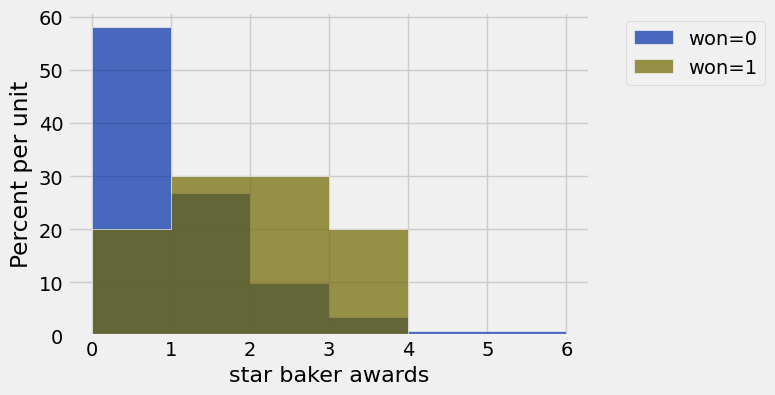

In [31]:
useful_bins = np.arange(0, 7)
bakers.hist("star baker awards", group = "won", bins = useful_bins)

**Question 2.5.** We want to figure out if there is a difference between the distribution of Star Baker awards between winners and non winners. 

What should the test statistic be? Which values of this test statistic support the null, and which values support the alternative? **Assign `test_option` to the number corresponding to the correct test statistic.**

1. Absolute value of the difference between the means between both groups; high values support the null
2. Absolute value of the difference between the means between both groups; low values support the null
3. Average Star Baker awards for winners - average Star Baker awards for non-winners; high values support the null
4. Average Star Baker awards for winners - average Star Baker awards for non-winners; low values support the null

Before moving on, confirm your answer with a peer or in the discussion forums.

_Hint:_ You should think about what measures we use to describe a distribution. 


In [32]:
test_option = 4

In [33]:
grader.check("q2_5")

q2_5 results: All test cases passed!

**Question 2.6.** Set `observed_difference` to the observed test statistic using the `means` table. 


In [34]:
observed_difference = means.column(1).item(1) - means.column(1).item(0)
observed_difference

0.8482142857142857

In [35]:
grader.check("q2_6")

q2_6 results: All test cases passed!

**Question 2.7.** Given a table like `bakers`, a label column `label_col`, and a values column `val_col`, write a function that calculates the appropriate test statistic.

*Hint:* Make sure that you are taking the directionality of our alternative hypothesis into account.


In [36]:
def find_test_stat(tbl, label_col, val_col):
    stat = tbl.select(label_col, val_col)
    means_table = stat.group(label_col, np.average)
    means = means_table.column(1)
    return means.item(1) - means.item(0)

find_test_stat(bakers, "won", "star baker awards")

0.8482142857142857

In [40]:
tbl = bakers
label_col = "won" 
val_col = "star baker awards"
stat = tbl.select(label_col, val_col)
stat.group(label_col, np.average)

won,star baker awards average
0,0.651786
1,1.5


In [ ]:
grader.check("q2_7")

When we run a simulation for A/B testing, we resample by **shuffling the labels** of the original sample. If the null hypothesis is true and the star baker award distributions are the same, we expect that the difference in mean star baker awards to not change when `"won"` labels are changed.

**Question 2.8.** Write a function `simulate_and_test_statistic` to compute one trial of our A/B test. Your function should run a simulation and return a test statistic.


In [42]:
def simulate_and_test_statistic(tbl, labels_col, values_col):
    shuffled_labels = tbl.sample(with_replacement = False).column(labels_col)
    shuffled_tbl = tbl.with_column(labels_col, shuffled_labels)
    return find_test_stat(shuffled_tbl, labels_col, values_col)

simulate_and_test_statistic(bakers, "won", "star baker awards")

-0.13214285714285712

In [43]:
grader.check("q2_8")

q2_8 results: All test cases passed!

**Question 2.9.** Simulate 5000 trials of our A/B test and store the test statistics in an array called `differences`.


In [ ]:
# This cell might take a couple seconds to run
differences = make_array()
for _ in range(5000):
    test_stat = simulate_and_test_statistic(bakers, 'won', 'star baker awards')
    differences = np.append(test_stat, differences)
                                                 
differences

In [ ]:
grader.check("q2_9")

Run the cell below to view a histogram of your simulated test statistics plotted with your observed test statistic.

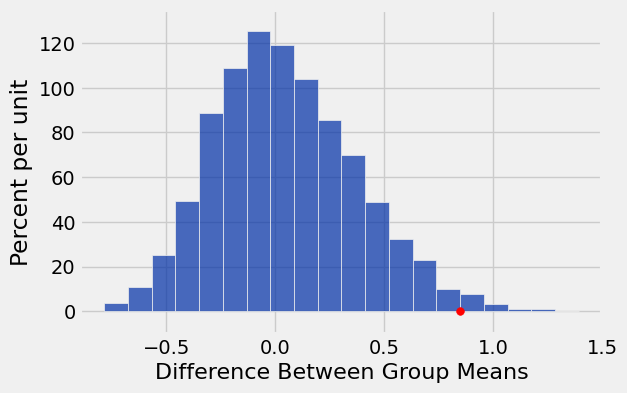

In [44]:
Table().with_column('Difference Between Group Means', differences).hist(bins=20)
plots.scatter(observed_difference, 0, color='red', s=30, zorder=2)
plots.ylim(-0.1, 1.35);

**Question 2.10.** Find the p-value for your test and assign it to `empirical_p`.


In [ ]:
empirical_p = np.count_nonzero(differences >= observed_difference) / 5000
empirical_p

In [ ]:
grader.check("q2_10")

**Question 2.11.** Using a 5% P-value cutoff, draw a conclusion about the null and alternative hypotheses. Describe your findings using simple, non-technical language. What does your analysis tell you about the association between star baker awards and winning? What can you claim about causation from your statistical analysis? Confirm your answer with a peer, instructor or in the discussion forums. 


Since the p-value is less than 0.05, we would reject the null hypothesis while adopting the alternative hypothesis at the same time. The contestants that win more awards are most likely to win their season of the show.

<p>&nbsp;</p>

`Good Job! You are done with this assignment!`

## Submission Instructions

Follow these steps to submit your work:

1. Save your notebook file:
   - Click on File -> Save Notebook, or simply click on the Save icon.
2. Restart Kernel and Run All Cells:
   - In the menu, go to Kernel → Restart Kernel and Run All Cells.
3. Verify your work:
   - Scroll through the notebook to ensure everything runs smoothly without unexpected error messages. 
   - In case of interruptions caused by execution errors, use "Run ==> Selected Cell and All Below" to continue execution. 
4. Save the notebook again to confirm all changes.
5. Create a duplicate notebook for submission:
   - In the Jupyter Notebook dashboard/homepage, create a duplicate of this notebook
   - Rename the duplicate from *assignment.ipynb_copy* to *assignment_FIRSTNAME_LASTNAME.ipynb* (e.g., *a01_TSANGYAO_CHEN.ipynb*) for submission.
   - Keep your original notebook file as a backup.
6. Upload your renamed notebook to Canvas.